In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt 
import torch
import zarr

from loader import spot_dataloader

In [167]:
z = zarr.open('../../.deepcell/spotnet/test.zarr')
X = z['X']
y = z['y']
y_inds = z['y_inds']

In [168]:
loader = spot_dataloader(X, y, y_inds, batch_size=1, augment=False)

In [169]:
dataloader = iter(loader)

In [170]:
image, labels = next(dataloader)


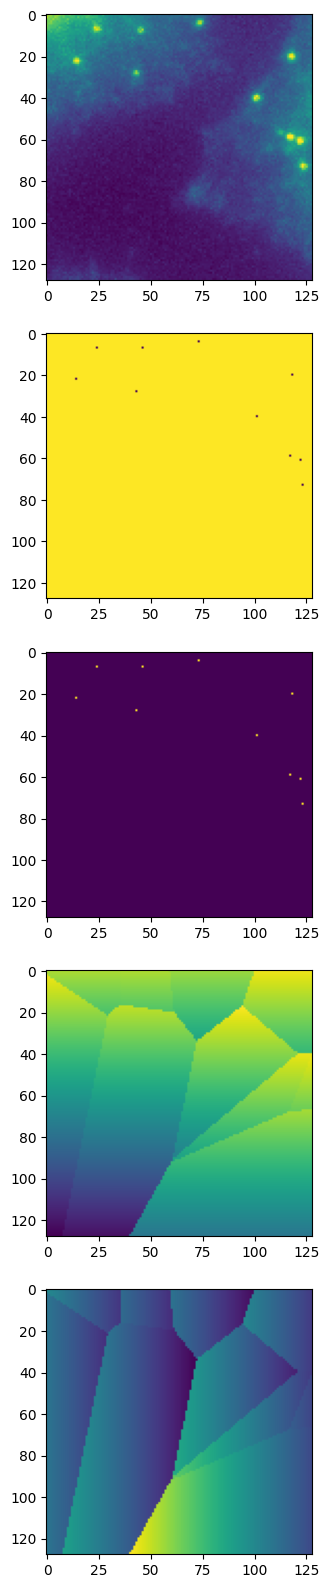

In [171]:
fig, ax = plt.subplots(5, figsize=(4,20))

ax[0].imshow(image.squeeze())
ax[1].imshow(labels['detections'][0,0].squeeze())
ax[2].imshow(labels['detections'][0,1].squeeze())
ax[3].imshow(labels['offsets'][0,0].squeeze())
ax[4].imshow(labels['offsets'][0,1].squeeze())

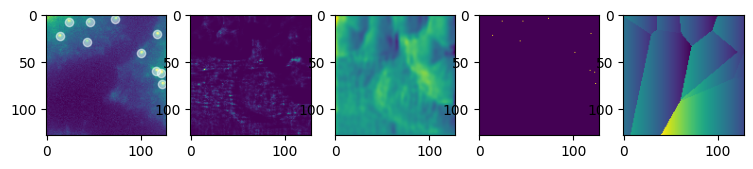

In [276]:
from dotnet import SpotNet

spotnet = SpotNet(norm_method=None)

checkpoint = torch.load('../data/model/current/saved_model_best_dict.pth')
spotnet.load_state_dict(checkpoint)
spotnet = spotnet.eval()

out = spotnet(image)

for k,v in out.items():
    out[k] = v.detach().cpu().numpy()

locations = np.argwhere(labels['detections'][0,1].numpy()).squeeze()

fig, ax = plt.subplots(1,5, figsize=(9,3))

ax[0].imshow(image.squeeze(), cmap='viridis')
ax[0].scatter(locations[:,1], locations[:,0], alpha=0.5, c='w')
ax[1].imshow(out['detections'][0,1], cmap='viridis')
ax[2].imshow(out['offsets'][0,1], cmap='viridis')

ax[3].imshow(labels['detections'][0,1])
ax[4].imshow(labels['offsets'][0,1])

In [188]:
from loss import DotNetLosses

loss = DotNetLosses(gamma=3, sigma=0.5)

In [ ]:
from dotnet import SpotNet

spotnet = SpotNet(norm_method=None)

# checkpoint = torch.load('../data/model/current/saved_model_best_dict.pth')
# spotnet.load_state_dict(checkpoint)
spotnet = spotnet.eval()

out = spotnet(image)

loss(out, labels)

tensor(0.0324, grad_fn=<DivBackward0>)